# Data Exploration: CBIS-DDSM Mammography Dataset

This notebook explores the Curated Breast Imaging Subset of the Digital Database for Screening Mammography (CBIS-DDSM), a publicly available dataset for breast cancer detection research.

## Objectives
1. Understand dataset structure and composition
2. Analyze class distribution and data splits
3. Visualize sample images with annotations
4. Examine data augmentation effects
5. Generate dataset statistics for reporting

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torchvision.transforms.functional as TF
import warnings
warnings.filterwarnings('ignore')

# Project imports
from src.data.dataset import CBISDDSMDataset
from src.data.transforms import get_transforms, IMAGENET_MEAN, IMAGENET_STD

# Paths
def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'configs').exists() and (candidate / 'src').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate project root from the current notebook kernel.')

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
DATA_DIR = PROJECT_ROOT / 'data'

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
%matplotlib inline


def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    image = tensor.detach().cpu() * std.cpu() + mean.cpu()
    return image.clamp(0, 1)


def show_tensor_image(ax, tensor, title):
    image = denormalize_image(tensor).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')


## 2. Dataset Structure Analysis

In [2]:
# Check data directory structure
print('Dataset structure:')
for root, dirs, files in os.walk(DATA_DIR, topdown=True):
    level = str(root).replace(str(DATA_DIR), '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent}{os.path.basename(root)}/' if level > 0 else f'{indent}{root}/')
    subindent = ' ' * 4 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files) - 3} more files')


Dataset structure:
/Users/grmim/Dev/ssl/data/
    .DS_Store
    csv/
        mass_case_description_train_set.csv
        calc_case_description_test_set.csv
        calc_case_description_train_set.csv
        ... and 3 more files
    jpeg/
        .DS_Store
        1.3.6.1.4.1.9590.100.1.2.391876226111657492320851639130860760300/
            1-232.jpg
        1.3.6.1.4.1.9590.100.1.2.379825687911615271529856495931027265130/
            1-266.jpg
        1.3.6.1.4.1.9590.100.1.2.332592954610458070926911632830870464887/
            1-060.jpg
            2-041.jpg
        1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/
            1-172.jpg
        1.3.6.1.4.1.9590.100.1.2.49233533712824105125846071150158695164/
            2-105.jpg
            1-253.jpg
        1.3.6.1.4.1.9590.100.1.2.254825922412029605400743366410867758253/
            2-007.jpg
            1-030.jpg
        1.3.6.1.4.1.9590.100.1.2.176318044711542036112483344693542984680/
            1-012.jpg
      

In [3]:
# Load and examine CSV files
csv_dir = DATA_DIR / 'csv'
csv_files = sorted(os.listdir(csv_dir))
print(f'\nCSV files in dataset: {len(csv_files)}')

for csv_file in csv_files:
    if csv_file.endswith('.csv'):
        filepath = csv_dir / csv_file
        df = pd.read_csv(filepath)
        print(f'\n{csv_file}:')
        print(f'  Shape: {df.shape}')
        print(f'  Columns: {list(df.columns)}')
        if 'pathology' in df.columns:
            print('  Pathology distribution:')
            print(df['pathology'].value_counts().to_string())



CSV files in dataset: 6

calc_case_description_test_set.csv:
  Shape: (326, 14)
  Columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
  Pathology distribution:
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67

calc_case_description_train_set.csv:
  Shape: (1546, 14)
  Columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
  Pathology distribution:
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474

dicom_info.csv:
  Shape: (10237, 38)
  Columns: ['file_path', 'image_path', 'Acc

## 3. Dataset Loading and Statistics

In [4]:
# Load datasets for different splits and abnormality types
transform = get_transforms('test', image_size=224)

datasets_info = []
for split in ['train', 'test']:
    for abn_type in ['mass', 'calc']:
        try:
            dataset = CBISDDSMDataset(
                split=split,
                abnormality_type=abn_type,
                transform=transform,
                data_dir=str(DATA_DIR),
            )
            counts = dataset.get_class_counts()
            datasets_info.append({
                'split': split,
                'abnormality_type': abn_type,
                'total': len(dataset),
                'benign': counts['benign'],
                'malignant': counts['malignant'],
                'benign_ratio': counts['benign'] / len(dataset) * 100,
                'malignant_ratio': counts['malignant'] / len(dataset) * 100,
            })
            print(f'Loaded {split} {abn_type}: {len(dataset)} samples')
        except Exception as e:
            print(f'Error loading {split} {abn_type}: {e}')

summary_df = pd.DataFrame(datasets_info)
summary_df


Loaded train mass: 1231 samples
Loaded train calc: 1227 samples
Loaded test mass: 361 samples
Loaded test calc: 38 samples


,split,abnormality_type,total,benign,malignant,benign_ratio,malignant_ratio
0,train,mass,1231,634,597,51.502843,48.497157
1,train,calc,1227,720,507,58.679707,41.320293
2,test,mass,361,218,143,60.387812,39.612188
3,test,calc,38,17,21,44.736842,55.263158


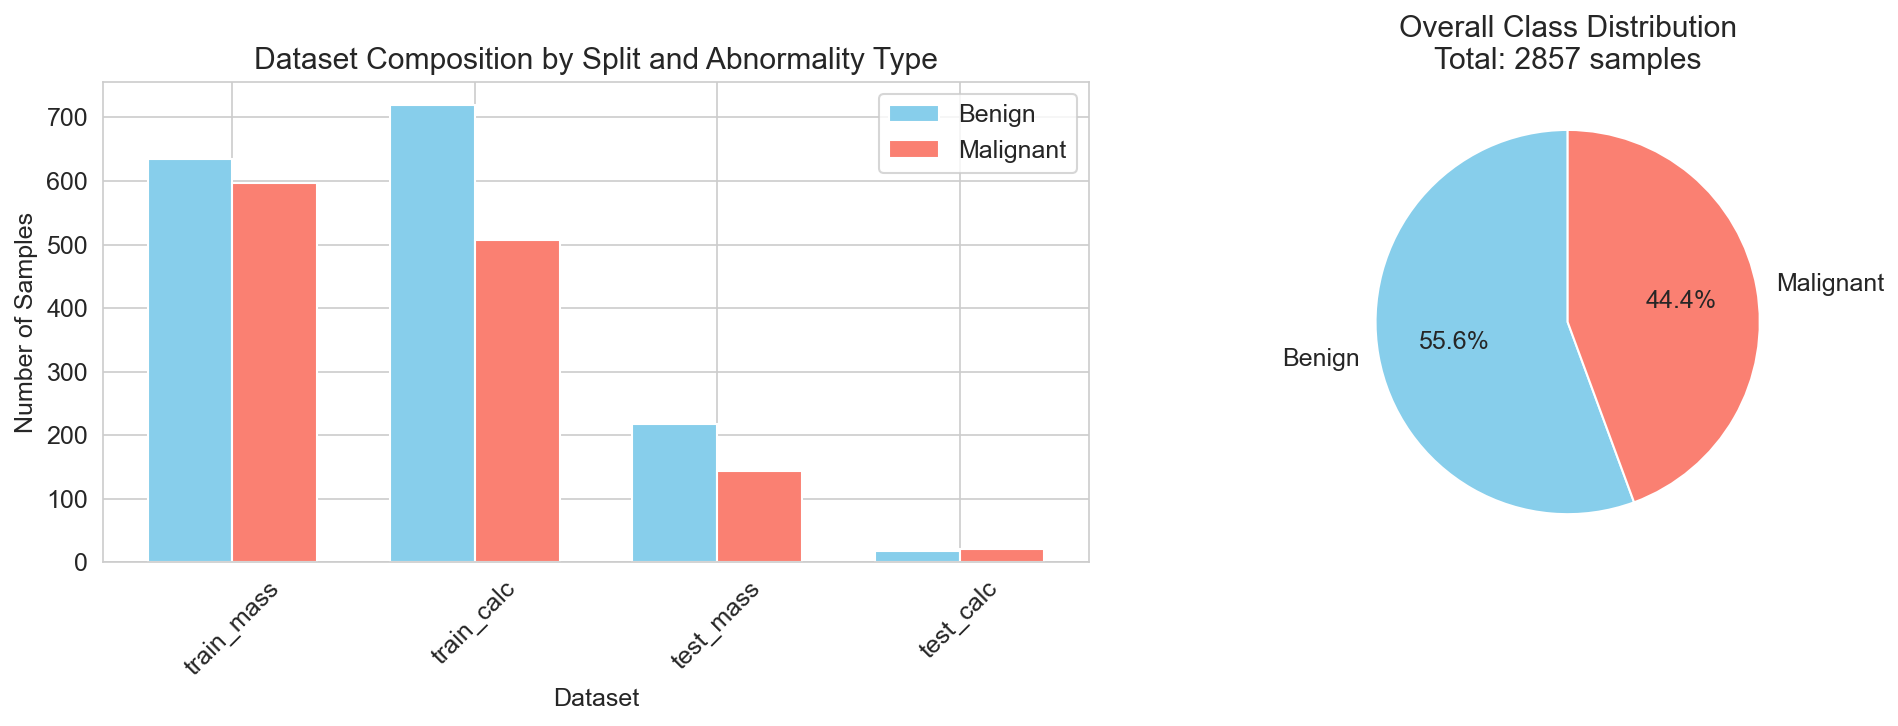

In [5]:
# Visualize dataset composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot: sample counts
ax = axes[0]
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df['benign'], width, label='Benign', color='skyblue')
ax.bar(x + width/2, summary_df['malignant'], width, label='Malignant', color='salmon')
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Samples')
ax.set_title('Dataset Composition by Split and Abnormality Type')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['split']}_{row['abnormality_type']}" for _, row in summary_df.iterrows()], rotation=45)
ax.legend()

# Pie chart: overall class distribution
ax = axes[1]
total_benign = summary_df['benign'].sum()
total_malignant = summary_df['malignant'].sum()
ax.pie([total_benign, total_malignant], 
       labels=['Benign', 'Malignant'], 
       autopct='%1.1f%%',
       colors=['skyblue', 'salmon'],
       startangle=90)
ax.set_title(f'Overall Class Distribution\nTotal: {total_benign + total_malignant} samples')

plt.tight_layout()
plt.show()

## 4. Sample Image Visualization

Found 634 benign and 597 malignant samples


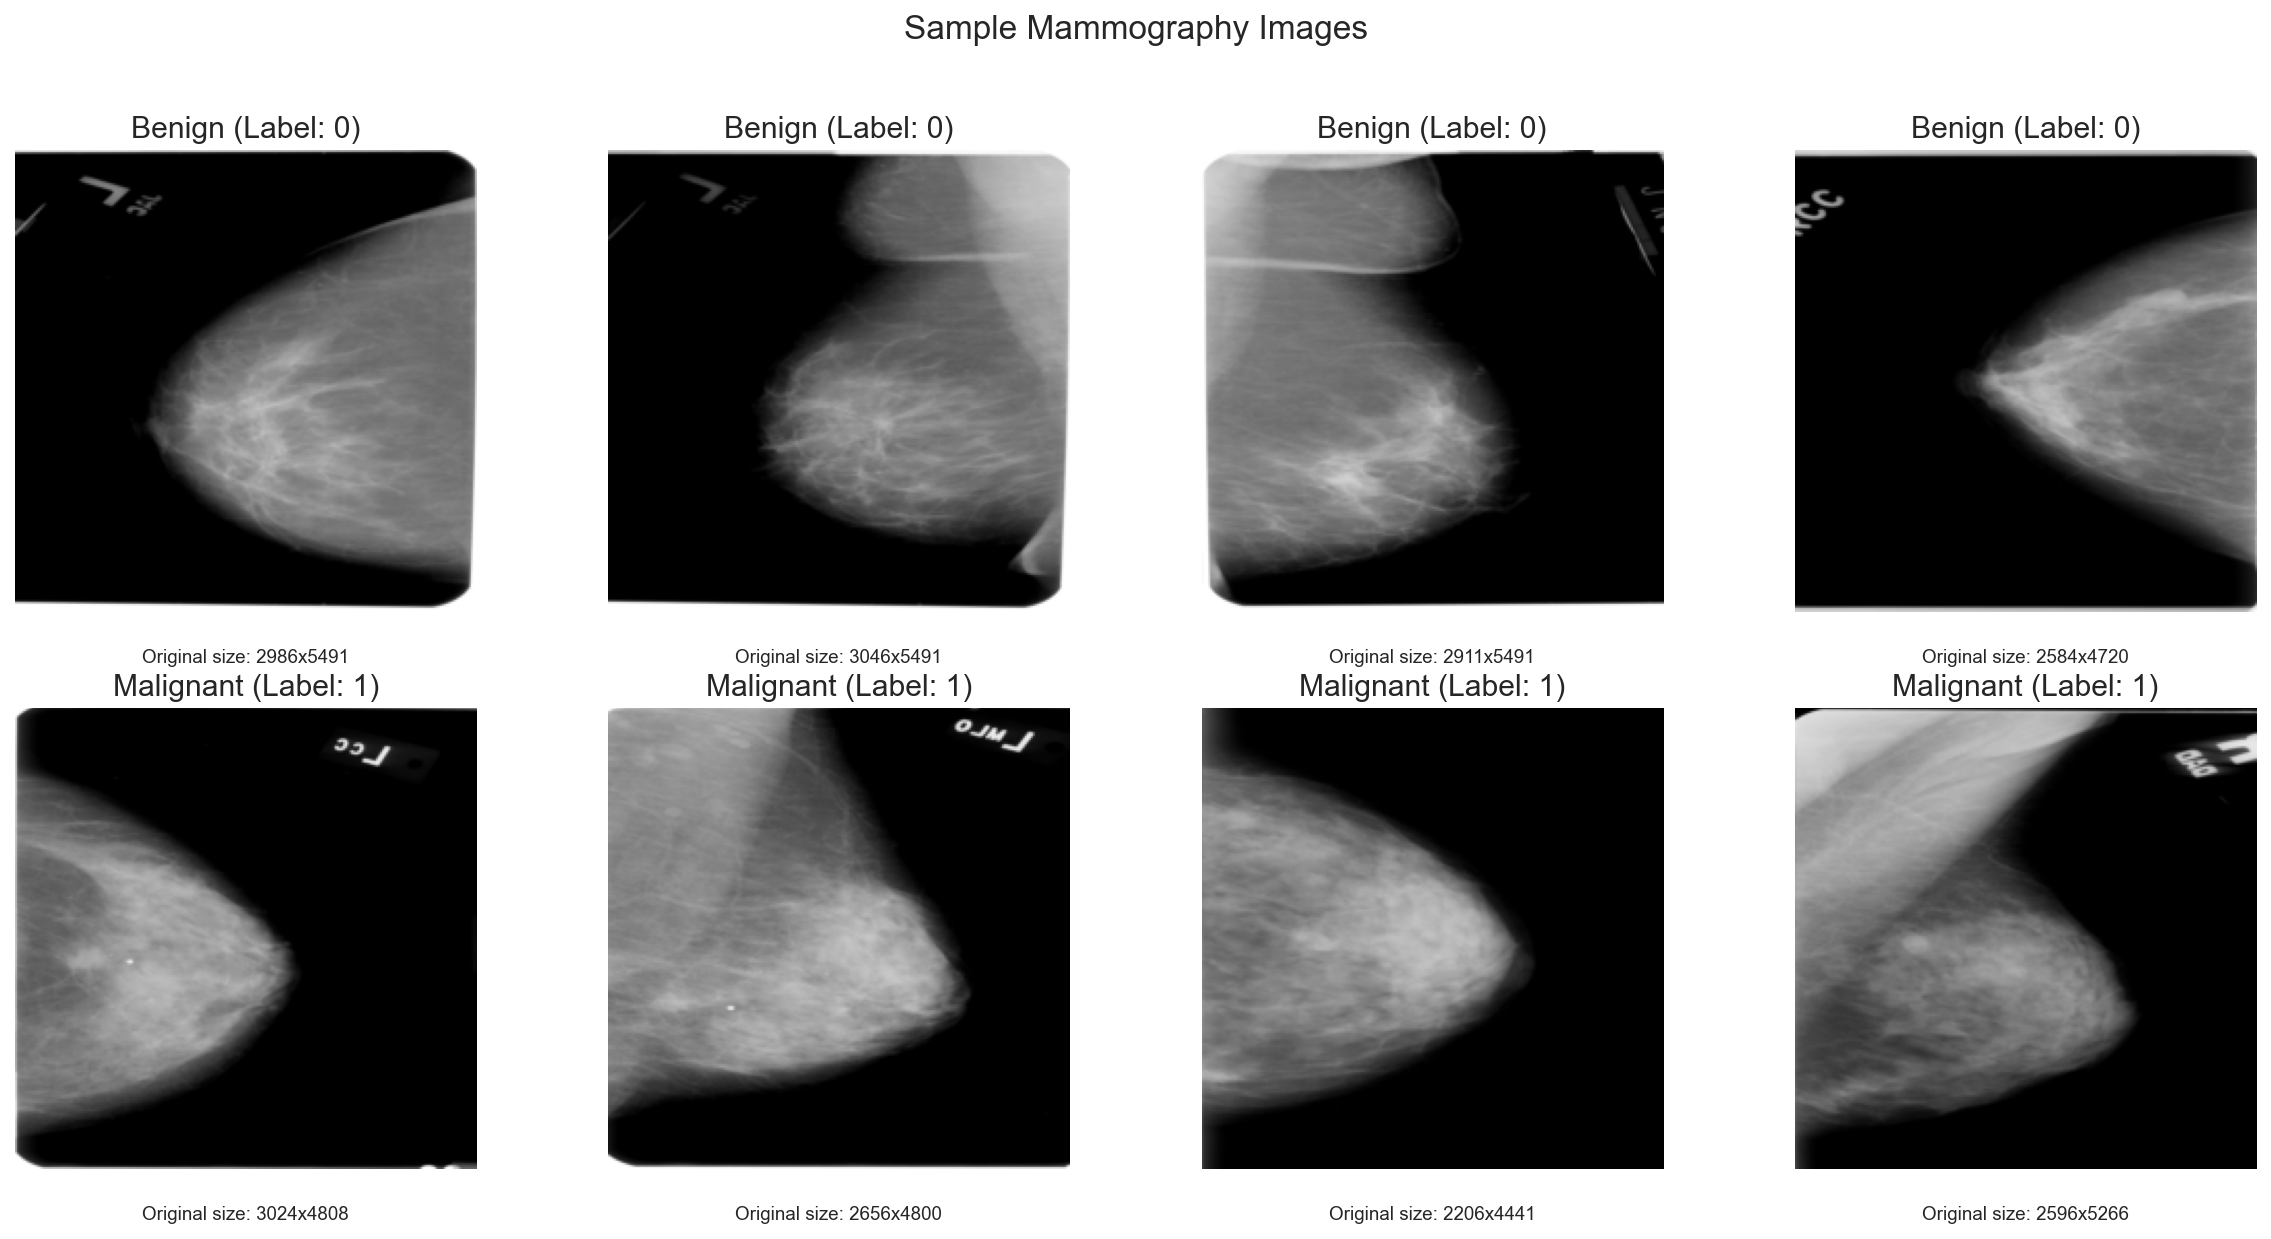

In [6]:
# Load a few samples with metadata
train_dataset = CBISDDSMDataset(
    split='train',
    abnormality_type='mass',
    transform=transform,
    data_dir=str(DATA_DIR),
)
raw_train_dataset = CBISDDSMDataset(
    split='train',
    abnormality_type='mass',
    transform=None,
    data_dir=str(DATA_DIR),
)

benign_indices = [idx for idx, label in enumerate(train_dataset.labels) if label == 0]
malignant_indices = [idx for idx, label in enumerate(train_dataset.labels) if label == 1]

print(f'Found {len(benign_indices)} benign and {len(malignant_indices)} malignant samples')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Mammography Images', fontsize=16, y=1.02)

for i, idx in enumerate(benign_indices[:4]):
    img_tensor, label = train_dataset[idx]
    raw_img, _ = raw_train_dataset[idx]
    ax = axes[0, i]
    show_tensor_image(ax, img_tensor, f'Benign (Label: {label})')
    ax.text(0.5, -0.08, f'Original size: {raw_img.size[0]}x{raw_img.size[1]}', transform=ax.transAxes,
            ha='center', va='top', fontsize=9)

for i, idx in enumerate(malignant_indices[:4]):
    img_tensor, label = train_dataset[idx]
    raw_img, _ = raw_train_dataset[idx]
    ax = axes[1, i]
    show_tensor_image(ax, img_tensor, f'Malignant (Label: {label})')
    ax.text(0.5, -0.08, f'Original size: {raw_img.size[0]}x{raw_img.size[1]}', transform=ax.transAxes,
            ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()


Original image sizes from dataset metadata:

Unique image dimensions found: 5759
   Rows  Columns
0   289      351
1  6256     3526
2  4126     1546
3    97       97
4  4560     3104
5  3931     1981
6   409      393
7   436      611
8  5056     3571
9  5491     2371


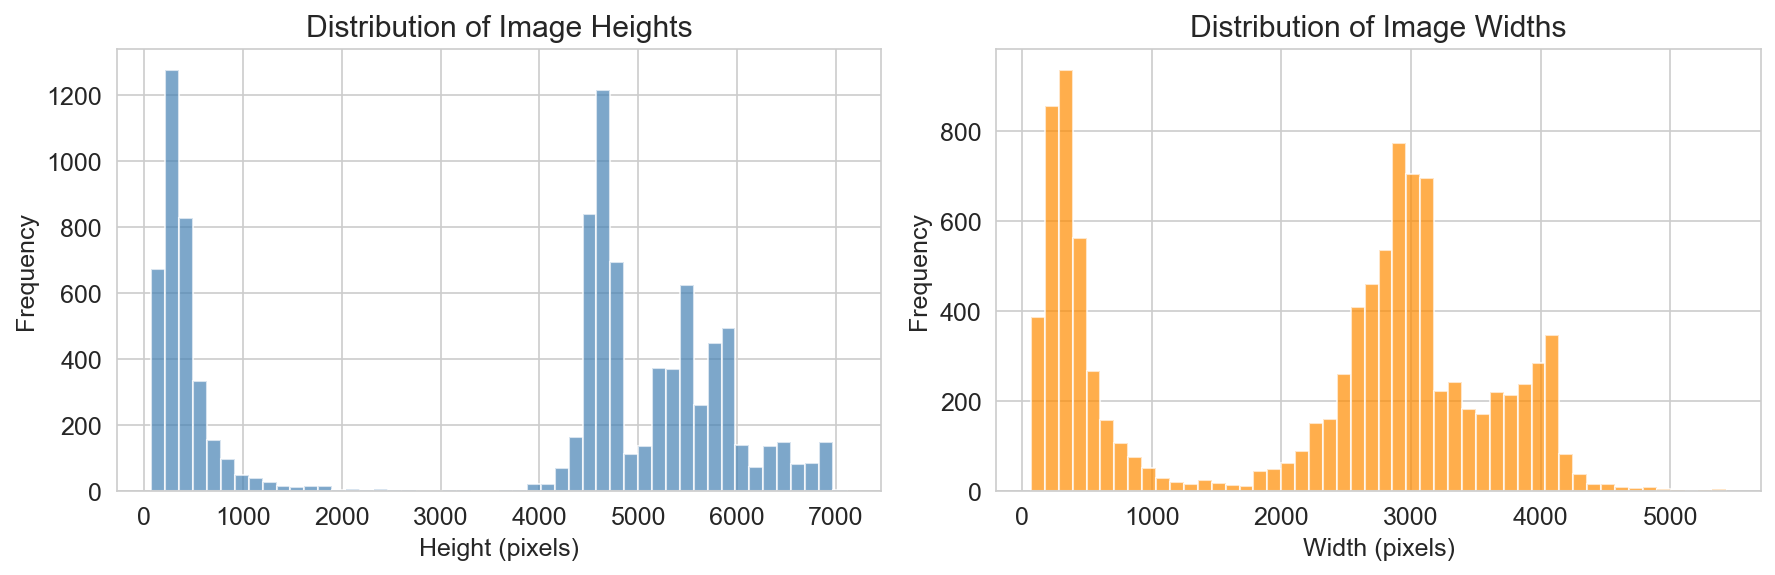

In [7]:
# Display original image sizes (before resizing)
print('Original image sizes from dataset metadata:')
dicom_info = pd.read_csv(DATA_DIR / 'csv' / 'dicom_info.csv')

if 'Rows' in dicom_info.columns and 'Columns' in dicom_info.columns:
    sizes = dicom_info[['Rows', 'Columns']].drop_duplicates()
    print(f'\nUnique image dimensions found: {len(sizes)}')
    print(sizes.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(dicom_info['Rows'], bins=50, alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Height (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Image Heights')

    axes[1].hist(dicom_info['Columns'], bins=50, alpha=0.7, color='darkorange')
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Image Widths')

    plt.tight_layout()
    plt.show()
else:
    print('Rows/Columns metadata not available in dicom_info.csv')


## 5. Data Augmentation Visualization

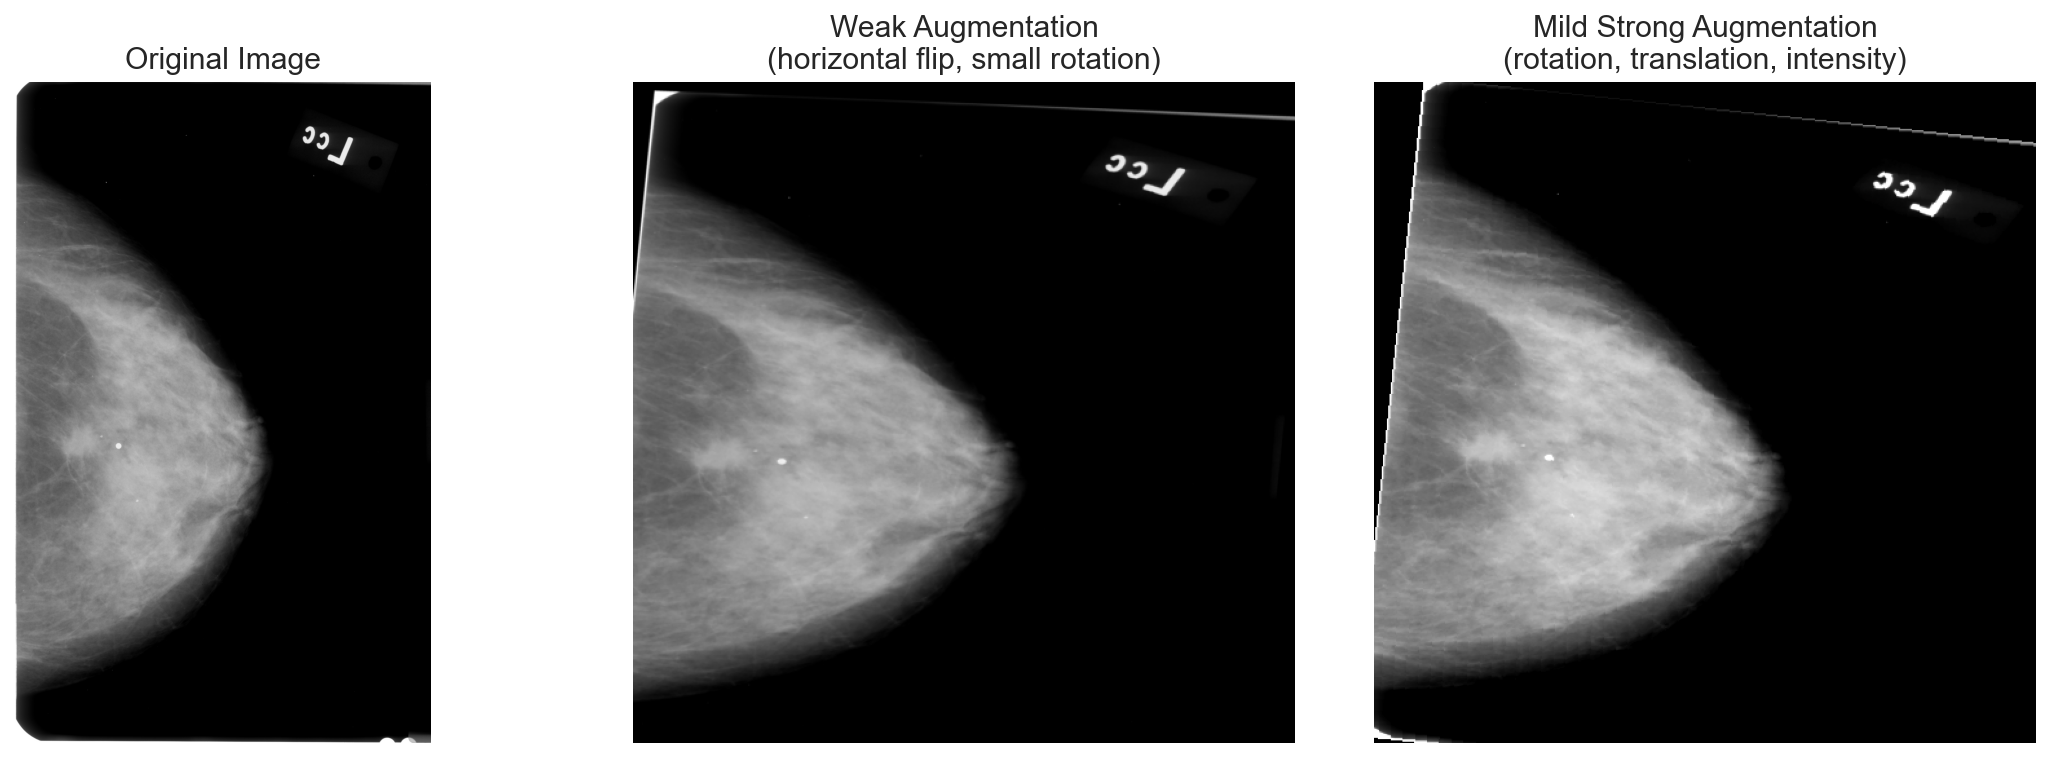

In [8]:
# Visualize different augmentation strategies
sample_tensor, sample_label = train_dataset[0]
sample_img_pil, _ = raw_train_dataset[0]

weak_aug = get_transforms('weak', image_size=512, config={
    'random_horizontal_flip': True,
    'random_vertical_flip': False,
    'random_rotation': 5,
    'color_jitter': 0.0,
})
strong_aug = get_transforms('mild_strong', image_size=512, random_horizontal_flip=True,
                            random_rotation=8.0, translate=(0.05, 0.05), brightness=0.08, contrast=0.12)

weak_augmented = weak_aug(sample_img_pil)
strong_augmented = strong_aug(sample_img_pil)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img_pil)
axes[0].set_title('Original Image')
axes[0].axis('off')

show_tensor_image(axes[1], weak_augmented, 'Weak Augmentation\n(horizontal flip, small rotation)')
show_tensor_image(axes[2], strong_augmented, 'Mild Strong Augmentation\n(rotation, translation, intensity)')

plt.tight_layout()
plt.show()


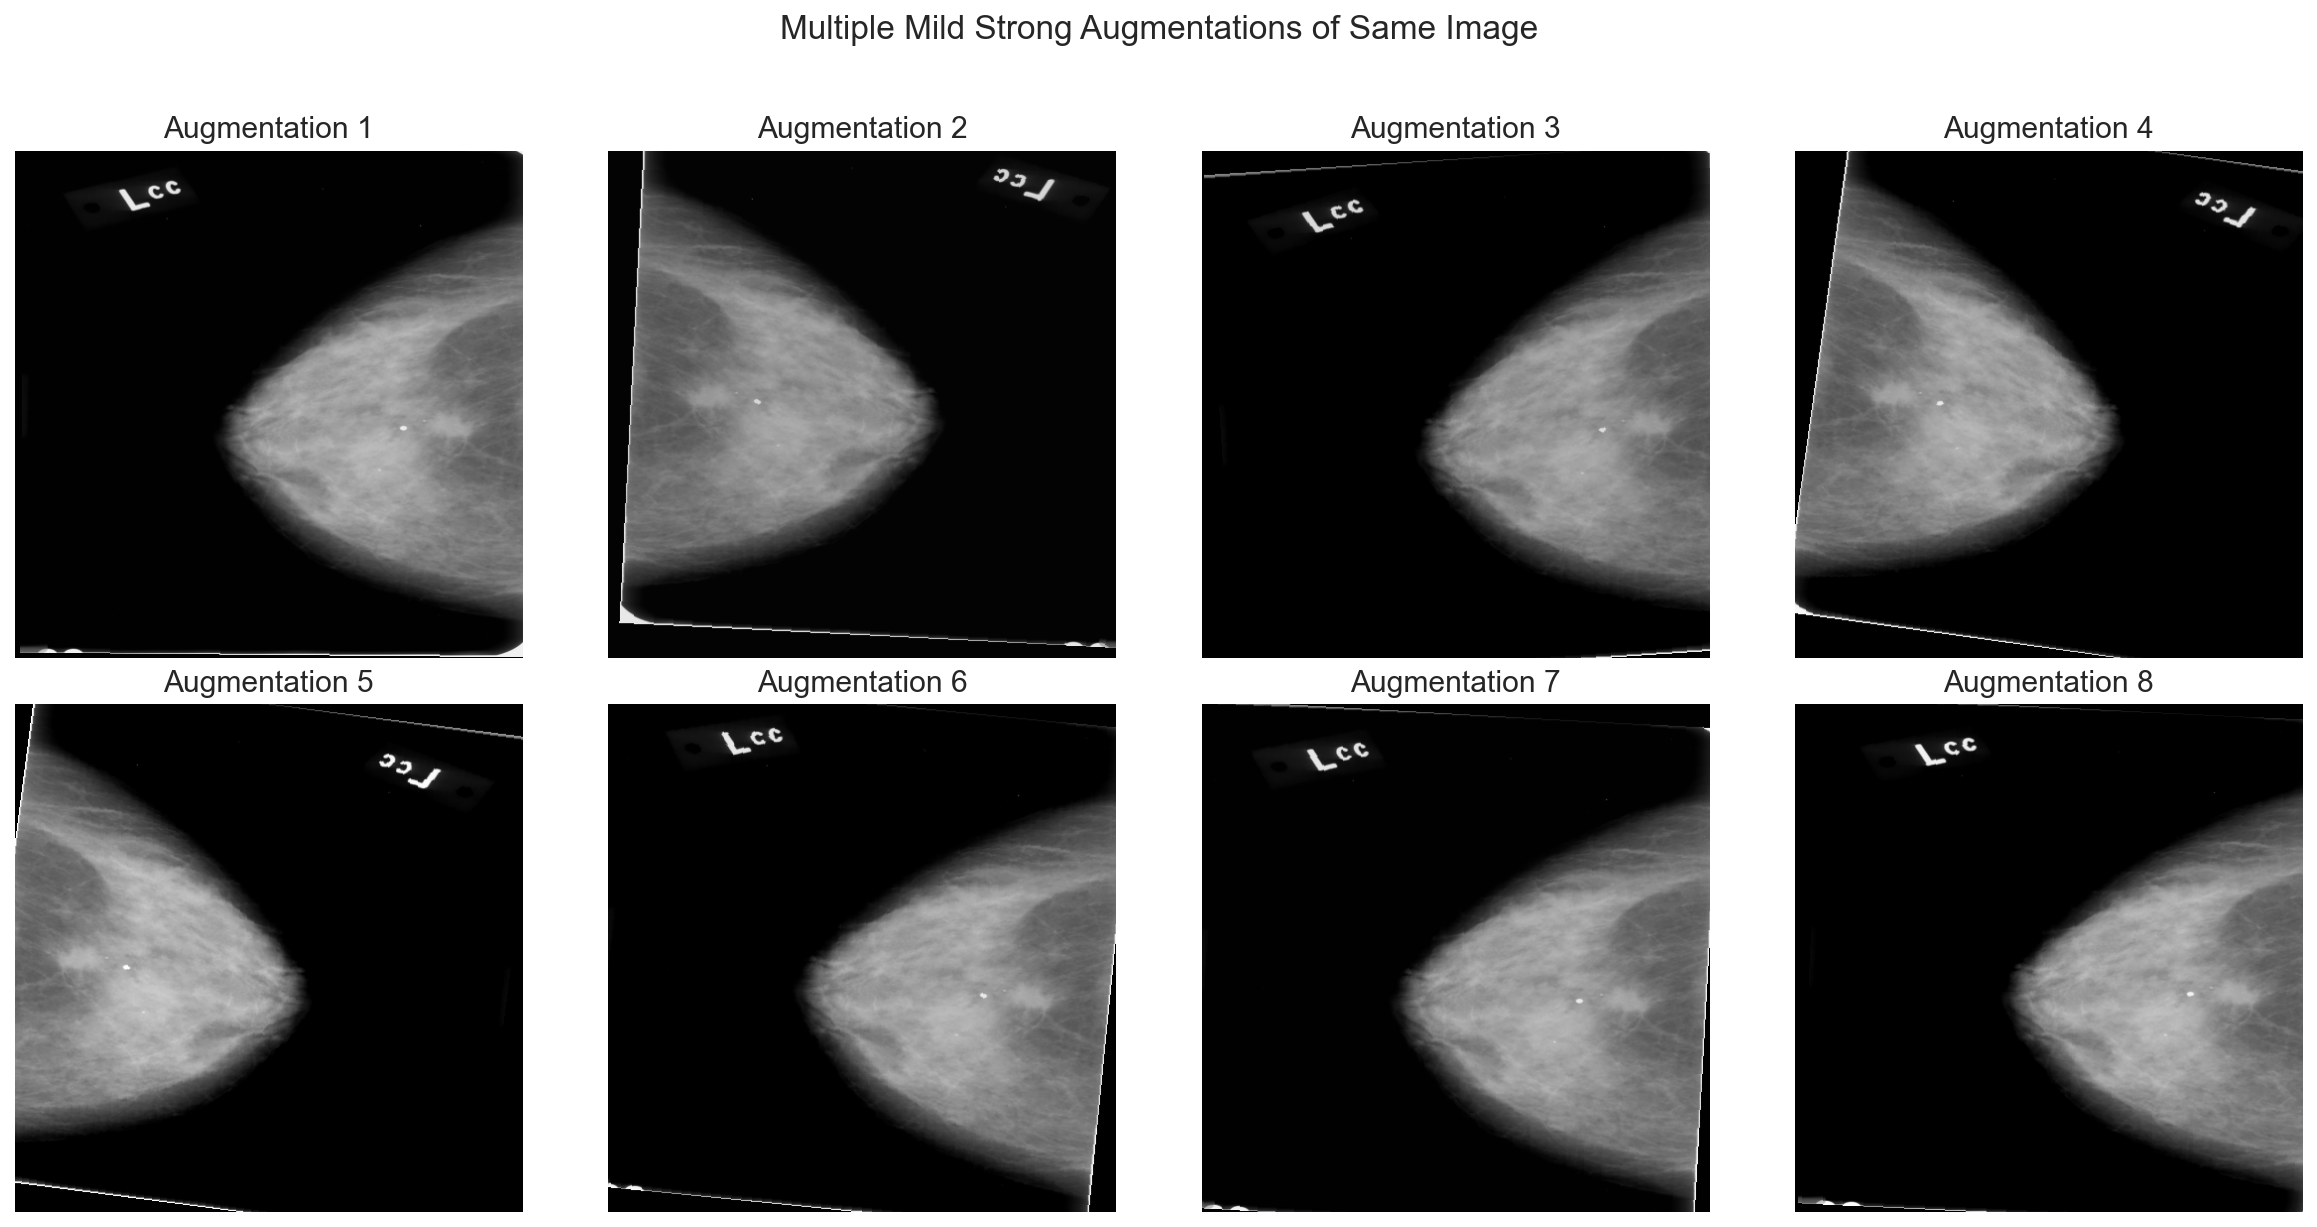

In [9]:
# Show multiple strong augmentations of the same image
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Multiple Mild Strong Augmentations of Same Image', fontsize=16, y=1.02)

for i in range(8):
    aug_img = strong_aug(sample_img_pil)
    ax = axes[i // 4, i % 4]
    show_tensor_image(ax, aug_img, f'Augmentation {i + 1}')

plt.tight_layout()
plt.show()


## 6. Metadata Analysis

Mass training set metadata:
Total records: 1318


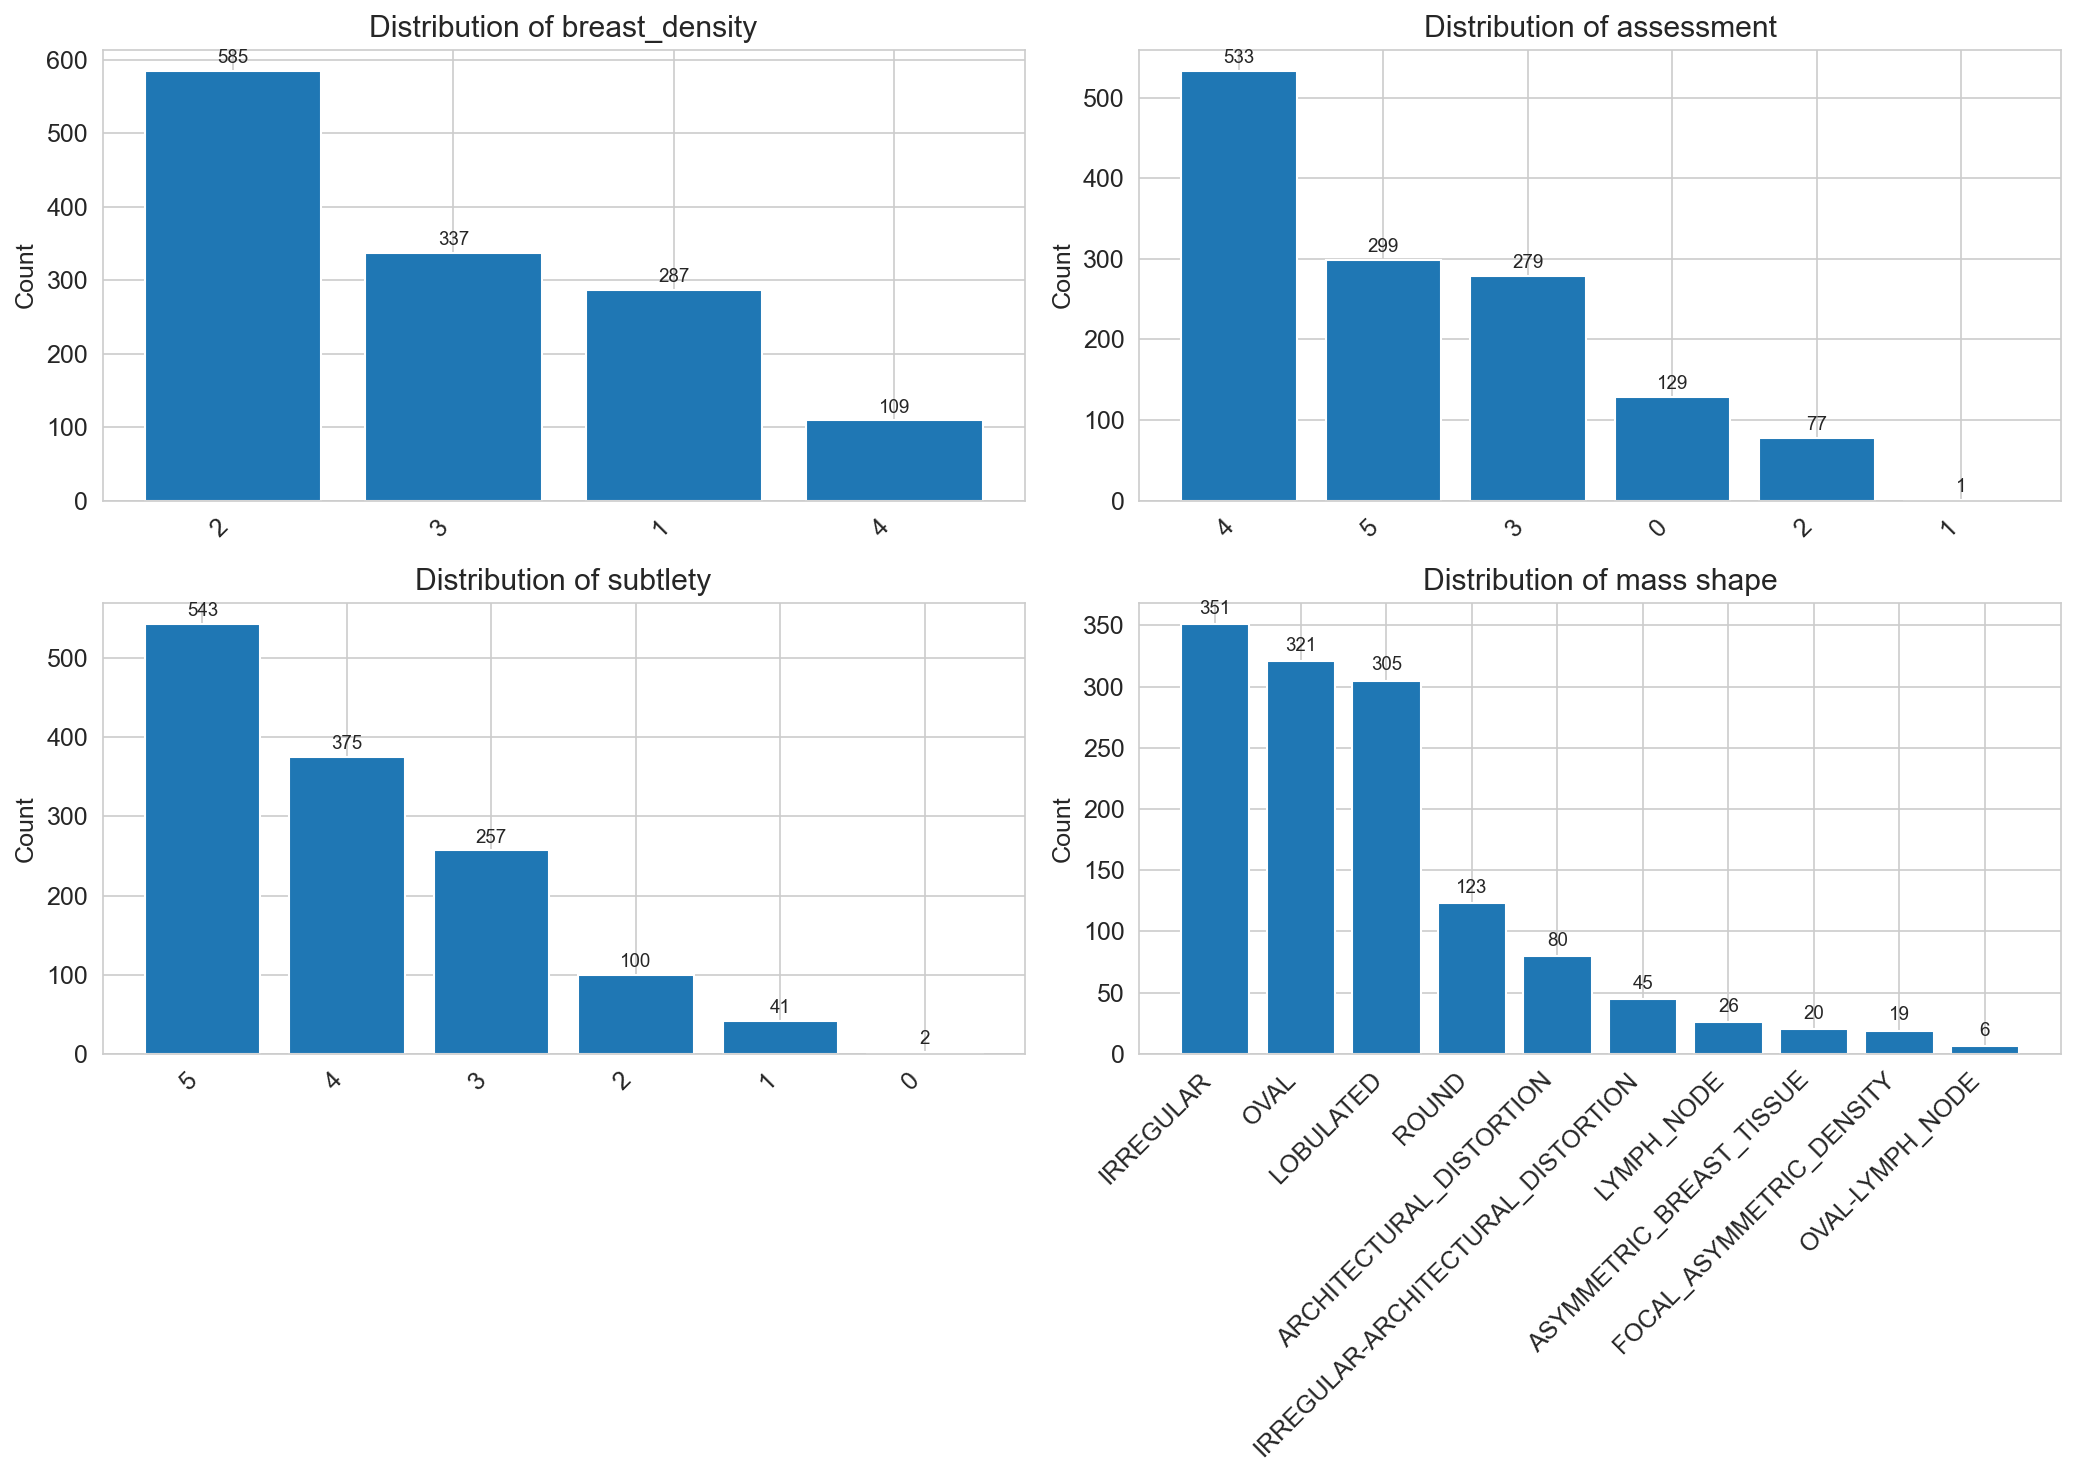

In [10]:
# Analyze additional metadata
mass_train = pd.read_csv(DATA_DIR / 'csv' / 'mass_case_description_train_set.csv')

print('Mass training set metadata:')
print(f'Total records: {len(mass_train)}')

metadata_cols = ['breast_density', 'assessment', 'subtlety', 'mass shape', 'mass margins']
available_cols = [col for col in metadata_cols if col in mass_train.columns]

n_plots = min(4, len(available_cols))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(available_cols[:4]):
    ax = axes[i]
    value_counts = mass_train[col].value_counts().head(10)
    if len(value_counts) > 0:
        bars = ax.bar(range(len(value_counts)), value_counts.values)
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
        ax.set_title(f'Distribution of {col}')
        ax.set_ylabel('Count')
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height + 5, f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

for ax in axes[n_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


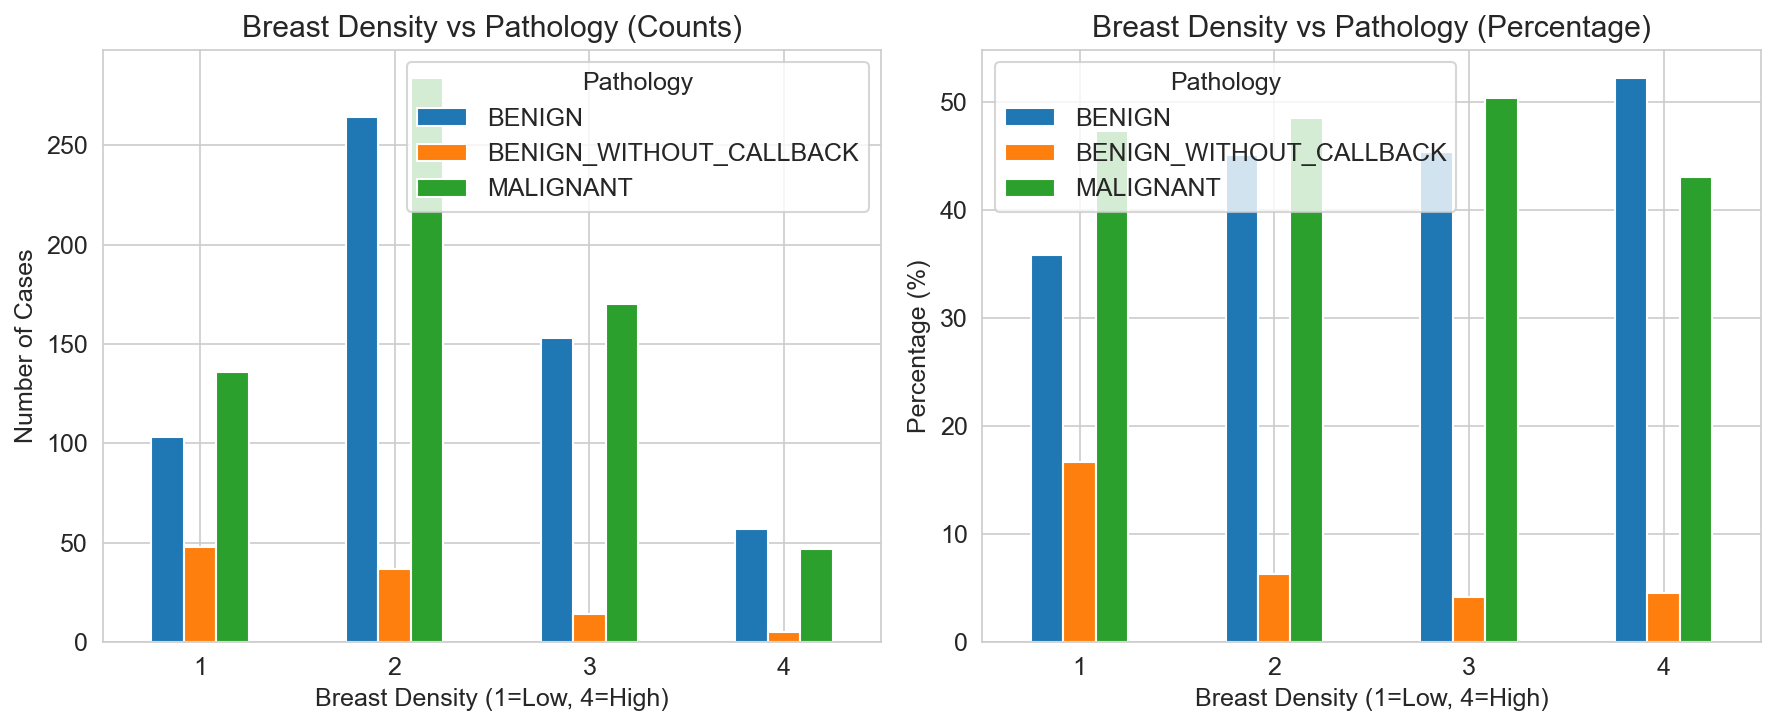

In [11]:
# Correlation between metadata and pathology
if 'breast_density' in mass_train.columns and 'pathology' in mass_train.columns:
    contingency = pd.crosstab(mass_train['breast_density'], mass_train['pathology'])
    contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    contingency.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Breast Density vs Pathology (Counts)')
    axes[0].set_xlabel('Breast Density (1=Low, 4=High)')
    axes[0].set_ylabel('Number of Cases')
    axes[0].legend(title='Pathology')
    axes[0].tick_params(axis='x', rotation=0)

    contingency_pct.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Breast Density vs Pathology (Percentage)')
    axes[1].set_xlabel('Breast Density (1=Low, 4=High)')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(title='Pathology')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print('Required metadata columns are missing for this analysis.')


## 7. Dataset Statistics for Reporting

In [12]:
# Generate comprehensive statistics for research papers
print('=' * 60)
print('DATASET STATISTICS FOR RESEARCH REPORTING')
print('=' * 60)

total_images = sum(1 for _ in DATA_DIR.rglob('*.jpg'))
print(f'\n1. Total JPEG images in dataset: {total_images:,}')

mass_train_df = pd.read_csv(DATA_DIR / 'csv' / 'mass_case_description_train_set.csv')
mass_test_df = pd.read_csv(DATA_DIR / 'csv' / 'mass_case_description_test_set.csv')

mass_train_clean = mass_train_df.dropna(subset=['pathology'])
mass_test_clean = mass_test_df.dropna(subset=['pathology'])

print('\n2. Mass abnormality dataset:')
print(f'   - Training samples: {len(mass_train_clean):,}')
print(f"     • Malignant: {sum(mass_train_clean['pathology'] == 'MALIGNANT'):,}")
print(f"     • Benign: {sum(mass_train_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])):,}")
print(f'   - Test samples: {len(mass_test_clean):,}')
print(f"     • Malignant: {sum(mass_test_clean['pathology'] == 'MALIGNANT'):,}")
print(f"     • Benign: {sum(mass_test_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])):,}")

calc_train_df = pd.read_csv(DATA_DIR / 'csv' / 'calc_case_description_train_set.csv')
calc_test_df = pd.read_csv(DATA_DIR / 'csv' / 'calc_case_description_test_set.csv')

calc_train_clean = calc_train_df.dropna(subset=['pathology'])
calc_test_clean = calc_test_df.dropna(subset=['pathology'])

print('\n3. Calcification abnormality dataset:')
print(f'   - Training samples: {len(calc_train_clean):,}')
print(f"     • Malignant: {sum(calc_train_clean['pathology'] == 'MALIGNANT'):,}")
print(f"     • Benign: {sum(calc_train_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])):,}")
print(f'   - Test samples: {len(calc_test_clean):,}')
print(f"     • Malignant: {sum(calc_test_clean['pathology'] == 'MALIGNANT'):,}")
print(f"     • Benign: {sum(calc_test_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])):,}")

print('\n4. Patient statistics:')
mass_patients_train = mass_train_clean['patient_id'].nunique()
mass_patients_test = mass_test_clean['patient_id'].nunique()
print(f'   - Mass: {mass_patients_train + mass_patients_test:,} unique patients')

calc_patients_train = calc_train_clean['patient_id'].nunique()
calc_patients_test = calc_test_clean['patient_id'].nunique()
print(f'   - Calcification: {calc_patients_train + calc_patients_test:,} unique patients')

if 'Rows' in dicom_info.columns and 'Columns' in dicom_info.columns:
    print('\n5. Image dimensions:')
    print(f"   - Min height: {dicom_info['Rows'].min():,} pixels")
    print(f"   - Max height: {dicom_info['Rows'].max():,} pixels")
    print(f"   - Mean height: {dicom_info['Rows'].mean():.0f} ± {dicom_info['Rows'].std():.0f} pixels")
    print(f"   - Min width: {dicom_info['Columns'].min():,} pixels")
    print(f"   - Max width: {dicom_info['Columns'].max():,} pixels")
    print(f"   - Mean width: {dicom_info['Columns'].mean():.0f} ± {dicom_info['Columns'].std():.0f} pixels")

print('\n' + '=' * 60)


DATASET STATISTICS FOR RESEARCH REPORTING

1. Total JPEG images in dataset: 10,237

2. Mass abnormality dataset:
   - Training samples: 1,318
     • Malignant: 637
     • Benign: 681
   - Test samples: 378
     • Malignant: 147
     • Benign: 231

3. Calcification abnormality dataset:
   - Training samples: 1,546
     • Malignant: 544
     • Benign: 1,002
   - Test samples: 326
     • Malignant: 129
     • Benign: 197

4. Patient statistics:
   - Mass: 892 unique patients
   - Calcification: 753 unique patients

5. Image dimensions:
   - Min height: 73 pixels
   - Max height: 7,111 pixels
   - Mean height: 3550 ± 2363 pixels
   - Min width: 68 pixels
   - Max width: 5,431 pixels
   - Mean width: 2180 ± 1374 pixels



## 8. Export Statistics

In [13]:
# Export statistics to CSV for reporting
export_stats = {
    'metric': [
        'total_jpeg_images',
        'mass_train_samples', 'mass_train_malignant', 'mass_train_benign',
        'mass_test_samples', 'mass_test_malignant', 'mass_test_benign',
        'calc_train_samples', 'calc_train_malignant', 'calc_train_benign',
        'calc_test_samples', 'calc_test_malignant', 'calc_test_benign',
        'mass_unique_patients', 'calc_unique_patients',
        'image_mean_height', 'image_std_height',
        'image_mean_width', 'image_std_width'
    ],
    'value': [
        total_images,
        len(mass_train_clean), sum(mass_train_clean['pathology'] == 'MALIGNANT'),
        sum(mass_train_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])),
        len(mass_test_clean), sum(mass_test_clean['pathology'] == 'MALIGNANT'),
        sum(mass_test_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])),
        len(calc_train_clean), sum(calc_train_clean['pathology'] == 'MALIGNANT'),
        sum(calc_train_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])),
        len(calc_test_clean), sum(calc_test_clean['pathology'] == 'MALIGNANT'),
        sum(calc_test_clean['pathology'].isin(['BENIGN', 'BENIGN_WITHOUT_CALLBACK'])),
        mass_patients_train + mass_patients_test,
        calc_patients_train + calc_patients_test,
        dicom_info['Rows'].mean() if 'Rows' in dicom_info.columns else 0,
        dicom_info['Rows'].std() if 'Rows' in dicom_info.columns else 0,
        dicom_info['Columns'].mean() if 'Columns' in dicom_info.columns else 0,
        dicom_info['Columns'].std() if 'Columns' in dicom_info.columns else 0,
    ]
}

stats_df = pd.DataFrame(export_stats)
export_path = NOTEBOOK_DIR / 'dataset_statistics.csv'
stats_df.to_csv(export_path, index=False)
print(f"Statistics exported to '{export_path.name}'")
print('\nFirst few rows:')
print(stats_df.head())


Statistics exported to 'dataset_statistics.csv'

First few rows:
                 metric    value
0     total_jpeg_images  10237.0
1    mass_train_samples   1318.0
2  mass_train_malignant    637.0
3     mass_train_benign    681.0
4     mass_test_samples    378.0


## 9. Conclusion and Key Findings

### Key Observations:
1. **Dataset Size**: CBIS-DDSM contains ~3,000 mammography images with pathology labels
2. **Class Balance**: Relatively balanced with slight variation across splits
3. **Image Resolution**: High variability in original sizes (requires resizing for DL)
4. **Metadata Richness**: Includes breast density, assessment scores, and abnormality characteristics
5. **Augmentation Effects**: Strong augmentations (RandAugment) create significant variation while preserving medical relevance

### Implications for SSL Research:
- Sufficient unlabeled data available for SSL (when treating some labeled data as unlabeled)
- Class balance reduces bias in pseudo-labeling
- Medical augmentations must preserve diagnostic features
- High-resolution images require careful memory management

### Next Steps:
1. Proceed to training experiments (see Notebook 02)
2. Analyze feature representations (see Notebook 03)
3. Evaluate model performance (see Notebook 04)